In [1]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

x = torch.randn(2,2).to('cuda')
print("Tensor on GPU:", x)

CUDA available: True
CUDA version: 12.1
Tensor on GPU: tensor([[ 0.4976, -1.3383],
        [ 0.3326, -0.6911]], device='cuda:0')


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115393


In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [6]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [7]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115393]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [8]:
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [9]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [10]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [11]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[53, 59,  6,  1, 58, 56, 47, 40],
        [49, 43, 43, 54,  1, 47, 58,  1],
        [13, 52, 45, 43, 50, 53,  8,  0],
        [ 1, 39,  1, 46, 53, 59, 57, 43]], device='cuda:0')
targets:
torch.Size([4, 8])
tensor([[59,  6,  1, 58, 56, 47, 40, 59],
        [43, 43, 54,  1, 47, 58,  1, 58],
        [52, 45, 43, 50, 53,  8,  0, 26],
        [39,  1, 46, 53, 59, 57, 43,  0]], device='cuda:0')
----
when input is [53] the target: 59
when input is [53, 59] the target: 6
when input is [53, 59, 6] the target: 1
when input is [53, 59, 6, 1] the target: 58
when input is [53, 59, 6, 1, 58] the target: 56
when input is [53, 59, 6, 1, 58, 56] the target: 47
when input is [53, 59, 6, 1, 58, 56, 47] the target: 40
when input is [53, 59, 6, 1, 58, 56, 47, 40] the target: 59
when input is [49] the target: 43
when input is [49, 43] the target: 43
when input is [49, 43, 43] the target: 54
when input is [49, 43, 43, 54] the target: 1
when input is [49, 43, 43, 54, 1] the 

In [12]:
print(xb)

tensor([[53, 59,  6,  1, 58, 56, 47, 40],
        [49, 43, 43, 54,  1, 47, 58,  1],
        [13, 52, 45, 43, 50, 53,  8,  0],
        [ 1, 39,  1, 46, 53, 59, 57, 43]], device='cuda:0')


In [13]:
eval_iters = 200

### BIGRAM LANG MODEL

In [14]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
n_embd = 32

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    # def generate(self, idx, max_new_tokens):
    #     # idx is (B,T) array of indices in the current context
    #     for _ in range(max_new_tokens):
    #         logits, loss = self(idx) # (B,T,C)
    #         logits = logits[:, -1, :] # becomes (B,C)
    #         probs = F.softmax(logits, dim=-1) # (B,C)
    #         idx_next = torch.multinomial(probs, num_samples=1) # (B,1)
    #         idx = torch.cat((idx, idx_next), dim=1) # append to the running sequence (B,T+1)
    #     return idx
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)
        return idx

In [15]:
vocab_size = len(chars)
model = BigramLanguageModel(vocab_size)
m = model.to(device)
logits, loss = m(xb, yb)
print("logits shape: ", logits.shape)
print("loss: ", loss)

logits shape:  torch.Size([32, 65])
loss:  tensor(4.3152, device='cuda:0', grad_fn=<NllLossBackward0>)


In [16]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=100)[0].tolist()))


?YCnx.DkRZ'Ndc.wd,ZTkOUlT-yHtK
b:!PTCNMBbzAU3:XaSvgO-33mMGd?gL3auhX:YVXhthXNNuyqcBMxv.tbfr3dXlrSZaAe


In [17]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.6479, val loss 4.6381
step 100: train loss 3.5084, val loss 3.5143
step 200: train loss 3.0410, val loss 3.0576
step 300: train loss 2.8771, val loss 2.8985
step 400: train loss 2.7904, val loss 2.7920
step 500: train loss 2.7275, val loss 2.7331
step 600: train loss 2.6815, val loss 2.6834
step 700: train loss 2.6479, val loss 2.6571
step 800: train loss 2.6308, val loss 2.6357
step 900: train loss 2.6032, val loss 2.6132
step 1000: train loss 2.5904, val loss 2.5860
step 1100: train loss 2.5720, val loss 2.5784
step 1200: train loss 2.5557, val loss 2.5582
step 1300: train loss 2.5409, val loss 2.5650
step 1400: train loss 2.5331, val loss 2.5457
step 1500: train loss 2.5333, val loss 2.5451
step 1600: train loss 2.5305, val loss 2.5477
step 1700: train loss 2.5284, val loss 2.5353
step 1800: train loss 2.5236, val loss 2.5455
step 1900: train loss 2.5159, val loss 2.5383
step 2000: train loss 2.5182, val loss 2.5447
step 2100: train loss 2.5201, val loss 2.5277


In [18]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=200)[0].tolist()))


HFwqcMPmRWf,fDldn3JyzyImmX
Yo3&$LMUofXimimq!!&AmOl;nd!lN!,be3 irwe-ERXhcim;lxqiHmlclroG EsSXUBLqWklJ.3:y!.lyWjbm!pelJljndAUXQl.$-huD3qcVcwvVy!?Uug!MOissXlUwtyfHJlvBPUHI.yBmdpjYelgvdE$qPmDmlqwTdqmltS?k


## SELF ATTENTION

### CREATING THE SELF ATTENTION CLASS (REFER TO selfattention.ipynb)

In [19]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,head_size)
        q = self.query(x) # (B,T,head_size)
        v = self.value(x) # (B,T,head_size)

        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B,T,head_size) @ (B,head_size,T) -> (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B,T,T)
        wei = F.softmax(wei, dim=-1) # (B,T,T)
        out = wei @ v # (B,T,T) @ (B,T,head_size) -> (B,T,head_size)
        return out

In [20]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.sa_head = Head(n_embd) #self attention head
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.sa_head(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [21]:
batch_size = 32
block_size = 8
max_iters = 5000
eval_interval = 500
learning_rate = 1e-3
eval_iters = 200
n_embd = 32

In [22]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.2299, val loss 4.2242
step 100: train loss 3.2154, val loss 3.2331
step 200: train loss 3.0574, val loss 3.0768
step 300: train loss 2.9459, val loss 2.9557
step 400: train loss 2.8165, val loss 2.8306
step 500: train loss 2.7037, val loss 2.7111
step 600: train loss 2.6362, val loss 2.6510
step 700: train loss 2.5926, val loss 2.5985
step 800: train loss 2.5659, val loss 2.5679
step 900: train loss 2.5370, val loss 2.5458
step 1000: train loss 2.5157, val loss 2.5245
step 1100: train loss 2.4996, val loss 2.5107
step 1200: train loss 2.4853, val loss 2.5067
step 1300: train loss 2.4792, val loss 2.4872
step 1400: train loss 2.4658, val loss 2.4770
step 1500: train loss 2.4742, val loss 2.4690
step 1600: train loss 2.4645, val loss 2.4709
step 1700: train loss 2.4594, val loss 2.4614
step 1800: train loss 2.4496, val loss 2.4578
step 1900: train loss 2.4381, val loss 2.4592
step 2000: train loss 2.4353, val loss 2.4340
step 2100: train loss 2.4343, val loss 2.4479


## MULTIHEAD ATTENTION

In [23]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return out

In [24]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.sa_heads(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [25]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.2101, val loss 4.2121
step 100: train loss 3.1789, val loss 3.2137
step 200: train loss 2.9409, val loss 2.9548
step 300: train loss 2.7776, val loss 2.7748
step 400: train loss 2.6829, val loss 2.6876
step 500: train loss 2.6155, val loss 2.6090
step 600: train loss 2.5620, val loss 2.5747
step 700: train loss 2.5380, val loss 2.5343
step 800: train loss 2.5040, val loss 2.5172
step 900: train loss 2.4793, val loss 2.4931
step 1000: train loss 2.4549, val loss 2.4668
step 1100: train loss 2.4463, val loss 2.4758
step 1200: train loss 2.4348, val loss 2.4433
step 1300: train loss 2.4212, val loss 2.4337
step 1400: train loss 2.4116, val loss 2.4232
step 1500: train loss 2.4023, val loss 2.4049
step 1600: train loss 2.3865, val loss 2.3988
step 1700: train loss 2.3874, val loss 2.3930
step 1800: train loss 2.3683, val loss 2.3993
step 1900: train loss 2.3684, val loss 2.3940
step 2000: train loss 2.3642, val loss 2.3711
step 2100: train loss 2.3546, val loss 2.3735


### INTRODUCING FEEDFORWARD NETWORK 
### SA -> FFN (PER TOKEN LEVEL) -> LOGITS CREATION

In [26]:
class FeedForward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, n_embd),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

In [27]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        self.ffwd = FeedForward(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.sa_heads(x) # (B,T,C)
        x = self.ffwd(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [28]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.1681, val loss 4.1694
step 100: train loss 3.1890, val loss 3.2030
step 200: train loss 3.0043, val loss 3.0199
step 300: train loss 2.8738, val loss 2.8735
step 400: train loss 2.7364, val loss 2.7344
step 500: train loss 2.6495, val loss 2.6415
step 600: train loss 2.5821, val loss 2.5885
step 700: train loss 2.5634, val loss 2.5582
step 800: train loss 2.5218, val loss 2.5206
step 900: train loss 2.5027, val loss 2.4977
step 1000: train loss 2.4915, val loss 2.4881
step 1100: train loss 2.4701, val loss 2.4675
step 1200: train loss 2.4565, val loss 2.4445
step 1300: train loss 2.4414, val loss 2.4553
step 1400: train loss 2.4076, val loss 2.4253
step 1500: train loss 2.4096, val loss 2.4107
step 1600: train loss 2.4007, val loss 2.3883
step 1700: train loss 2.3847, val loss 2.3923
step 1800: train loss 2.3819, val loss 2.3848
step 1900: train loss 2.3597, val loss 2.3752
step 2000: train loss 2.3551, val loss 2.3561
step 2100: train loss 2.3516, val loss 2.3557


#### ADDING THE TRANSFORMER BLOCK FOR "INTERSPERSING" THE OPERATIONS "COMMUNICATION" (MULTIHEAD ATTENTION) AND "COMPUTATION" (FFN)

In [29]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa_heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)

    def forward(self, x):
        x = self.sa_heads(x)
        x = self.ffwd(x)
        return x

In [30]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.blocks = nn.Sequential(
            Block(n_embd, n_head=4),
            Block(n_embd, n_head=4),
            Block(n_embd, n_head=4),
        )
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [31]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.1763, val loss 4.1778
step 100: train loss 3.3124, val loss 3.3471
step 200: train loss 3.2612, val loss 3.2795
step 300: train loss 3.1544, val loss 3.1537
step 400: train loss 3.1284, val loss 3.1217
step 500: train loss 3.1086, val loss 3.0958
step 600: train loss 3.0668, val loss 3.0633
step 700: train loss 2.9560, val loss 2.9712
step 800: train loss 2.8436, val loss 2.8470
step 900: train loss 2.7926, val loss 2.7937
step 1000: train loss 2.7096, val loss 2.7187
step 1100: train loss 2.6833, val loss 2.6726
step 1200: train loss 2.6623, val loss 2.6548
step 1300: train loss 2.6264, val loss 2.6175
step 1400: train loss 2.6020, val loss 2.6029
step 1500: train loss 2.5857, val loss 2.5818
step 1600: train loss 2.5747, val loss 2.5506
step 1700: train loss 2.5562, val loss 2.5484
step 1800: train loss 2.5274, val loss 2.5219
step 1900: train loss 2.5191, val loss 2.5047
step 2000: train loss 2.5107, val loss 2.5058
step 2100: train loss 2.4884, val loss 2.4938


### RESIDUAL CONNECTIONS

##### WHAT HAPPENED BEFORE WAS, THE NEURAL NETWORK BECAME SO DENSE (DEEP NEURAL NET), THUS MAKING COMPUTATION VERY HEAVY, TO SOLVE THIS RESIDUAL CONNECTIONS WERE INTRODUCED

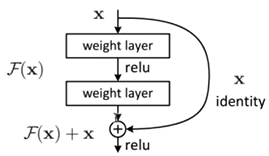

In [32]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa_heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)

    def forward(self, x):
        x = x + self.sa_heads(x)
        x = x + self.ffwd(x)
        return x

### USING PROJECTION INSTEAD OF SIMPLY CONCATINATING OUTPUTS OF MULTIHEAD

In [33]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

In [34]:
class FeedForward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd)
        )

    def forward(self, x):
        return self.net(x)

In [35]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.7300, val loss 4.7312
step 100: train loss 2.8676, val loss 2.9018
step 200: train loss 2.6245, val loss 2.6386
step 300: train loss 2.4873, val loss 2.5013
step 400: train loss 2.4338, val loss 2.4360
step 500: train loss 2.3874, val loss 2.4077
step 600: train loss 2.3607, val loss 2.3555
step 700: train loss 2.3340, val loss 2.3543
step 800: train loss 2.3280, val loss 2.3338
step 900: train loss 2.3088, val loss 2.3169
step 1000: train loss 2.2779, val loss 2.2891
step 1100: train loss 2.2401, val loss 2.2670
step 1200: train loss 2.2530, val loss 2.2467
step 1300: train loss 2.2266, val loss 2.2281
step 1400: train loss 2.2153, val loss 2.2294
step 1500: train loss 2.2005, val loss 2.2278
step 1600: train loss 2.1893, val loss 2.2074
step 1700: train loss 2.1545, val loss 2.2046
step 1800: train loss 2.1675, val loss 2.2090
step 1900: train loss 2.1379, val loss 2.2020
step 2000: train loss 2.1463, val loss 2.1917
step 2100: train loss 2.1434, val loss 2.1787


In [36]:
print(decode(model.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=300)[0].tolist()))



Go Wild to do piick, word, bour was in hime sto-Ling enour unde and thrupted so;
And hink:
't thy all on,
Thag Pre?

KING HUSH:-
Luch stidby sardads.
Wich Eght my din cour aye tey ire to chan thove youn pays, bemary.
You come wherm so a and sevie?

Now the me ladand who-mablight thy wetived,
Thou c


### LAYER NORMALIZATION

In [37]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa_heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa_heads(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

##### ADDING LAYERNORM LAYER AFTER BLOCKS AND BEFORE LMHEAD

In [38]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        # self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        # self.ffwd = FeedForward(n_embd)
        # self.lm_head = nn.Linear(n_embd, vocab_size)
        self.blocks = nn.Sequential(
            Block(n_embd, n_head=4),
            Block(n_embd, n_head=4),
            Block(n_embd, n_head=4),
            nn.LayerNorm(n_embd),
        )
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        # x = self.sa_heads(x) # (B,T,C)
        # x = self.ffwd(x) # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [39]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.4021, val loss 4.3916
step 100: train loss 2.9562, val loss 2.9768
step 200: train loss 2.6614, val loss 2.6669
step 300: train loss 2.5381, val loss 2.5233
step 400: train loss 2.4520, val loss 2.4552
step 500: train loss 2.4131, val loss 2.4233
step 600: train loss 2.3708, val loss 2.3848
step 700: train loss 2.3470, val loss 2.3522
step 800: train loss 2.3326, val loss 2.3426
step 900: train loss 2.2937, val loss 2.3016
step 1000: train loss 2.2712, val loss 2.2788
step 1100: train loss 2.2497, val loss 2.2669
step 1200: train loss 2.2365, val loss 2.2461
step 1300: train loss 2.2024, val loss 2.2248
step 1400: train loss 2.1948, val loss 2.2320
step 1500: train loss 2.1971, val loss 2.2141
step 1600: train loss 2.1791, val loss 2.1985
step 1700: train loss 2.1600, val loss 2.2089
step 1800: train loss 2.1409, val loss 2.1857
step 1900: train loss 2.1523, val loss 2.1742
step 2000: train loss 2.1458, val loss 2.1766
step 2100: train loss 2.1178, val loss 2.1684


## SCALING UP !!!!

##### c1 changing hyperparameters

In [41]:
batch_size = 64
block_size = 256
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2


##### c2 adding dropouts

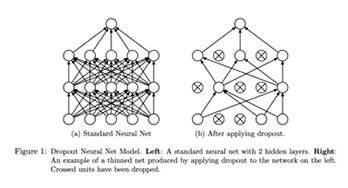

In [42]:
class FeedForward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)
    
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,head_size)
        q = self.query(x) # (B,T,head_size)
        v = self.value(x) # (B,T,head_size)

        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B,T,head_size) @ (B,head_size,T) -> (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B,T,T)
        wei = F.softmax(wei, dim=-1) # (B,T,T)
        wei = self.dropout(wei)
        out = wei @ v # (B,T,T) @ (B,T,head_size) -> (B,T,head_size)
        return out

#### c3 introduced n_layers for number of blocks and ln_f -> layernorm after blocks and before lm_head 

In [43]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        # self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        # self.ffwd = FeedForward(n_embd)
        # self.lm_head = nn.Linear(n_embd, vocab_size)
        # self.blocks = nn.Sequential(
        #     Block(n_embd, n_head=4),
        #     Block(n_embd, n_head=4),
        #     Block(n_embd, n_head=4),
        #     nn.LayerNorm(n_embd),
        # )
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [44]:
model = BigramLanguageModel(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

for steps in range(max_iters):
    if steps % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.3314, val loss 4.3344
step 500: train loss 1.7073, val loss 1.8625
step 1000: train loss 1.3628, val loss 1.5845
step 1500: train loss 1.2430, val loss 1.5231
step 2000: train loss 1.1592, val loss 1.4928
step 2500: train loss 1.0927, val loss 1.4865
step 3000: train loss 1.0318, val loss 1.5015
step 3500: train loss 0.9676, val loss 1.5204
step 4000: train loss 0.9096, val loss 1.5573
step 4500: train loss 0.8510, val loss 1.5854
0.9351754188537598


In [47]:
print(decode(model.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=10000)[0].tolist()))


When he express Coriod will be vulgar.

KING EDWARD IV:
My Lord of Warwick, where stand you tell the fruit.

KING EDWARD IV:
What, wilt thou see'st of so strong Edward's wife??

GLOUCESTER:
Then Beshall by Edward's love, but thou plain.

KING EDWARD IV:
That 'milgrimy thou fact, greatern name,
Not will make thinking befit.
Left both not this time wrong'd
Upbrague faults; thou wilthout, if thou be,
For my early drink of finger, as I did,
Ere now must lie in my eye--mine evils,
Now, if then be ready's endertation
Never robbed in idle best;
Or I conceive myself, all I did. The nobles
To see go: but dare her coming with him,
'Tis give to four sorrow to courter-joint
A way the grater of patience, and a fall
Will makt whe eagle friends to enter dwell.

CLARENCE:
Ah, by the which you seem your grace to swear!

Boy:
I thank thee, grand is chief; for the eyes
Of displeasure never beg: turn thee did;
For one death he is barbear the envy:
Wand left he use this favourity bray:
'Tis rid beautes fo